## Regression with Categorical Outcome Variable: NBA Data Set

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
#Import Data
NBA = pd.read_csv("/content/drive/MyDrive/Sports Performance Analytics Michigan/Course 3 - Prediction Models with Sports Data/Week 1 Content/Week 1 Assignment Part 1/NBA_Games2.csv")

In [ ]:
# extract 2017 regular season records, named “NBA _2017”. The regular season games can be defined with a Season ID equal to 22017 and a Game ID less than 1000000000 (these filters will exclude preseason games).
NBA_reg_2017 =  NBA[(NBA.SEASON_ID == 22017) & (NBA.GAME_ID < 1000000000)].copy()
display(NBA_reg_2017)

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
101,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701214,2018-04-10,...,8,31,39,27,10,3,10,24,-8.0,0
102,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701202,2018-04-08,...,5,32,37,23,7,4,13,19,6.0,1
103,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701184,2018-04-06,...,7,43,50,24,5,5,18,22,6.0,1
104,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701172,2018-04-04,...,10,38,48,20,5,6,15,16,-29.0,0
105,Atlanta,Atlanta Hawks,1610612737,Hawks,Atlanta,1949,22017,ATL,21701158,2018-04-03,...,12,37,49,24,10,1,15,15,-3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18106,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700070,2017-10-27,...,11,33,44,16,6,5,9,14,-16.0,0
18107,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700055,2017-10-25,...,10,40,50,17,5,5,14,16,17.0,1
18108,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700044,2017-10-23,...,10,38,48,17,3,5,14,21,-7.0,0
18109,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700017,2017-10-20,...,12,45,57,17,5,4,21,18,18.0,1


In [ ]:
# Explore the dataset using some useful commands.
NBA_reg_2017.shape

(2378, 33)

In [ ]:
NBA_reg_2017.columns

Index(['CITY', 'TEAM_NAME', 'TEAM_ID', 'NICKNAME', 'STATE', 'YEAR_FOUNDED',
       'SEASON_ID', 'TEAM_ABBREVIATION', 'GAME_ID', 'GAME_DATE', 'MATCHUP',
       'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK',
       'TOV', 'PF', 'PLUS_MINUS', 'WIN'],
      dtype='object')

In [ ]:
NBA_reg_2017.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2378 entries, 101 to 18110
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CITY               2378 non-null   object 
 1   TEAM_NAME          2378 non-null   object 
 2   TEAM_ID            2378 non-null   int64  
 3   NICKNAME           2378 non-null   object 
 4   STATE              2378 non-null   object 
 5   YEAR_FOUNDED       2378 non-null   int64  
 6   SEASON_ID          2378 non-null   int64  
 7   TEAM_ABBREVIATION  2378 non-null   object 
 8   GAME_ID            2378 non-null   int64  
 9   GAME_DATE          2378 non-null   object 
 10  MATCHUP            2378 non-null   object 
 11  WL                 2378 non-null   object 
 12  MIN                2378 non-null   int64  
 13  PTS                2378 non-null   int64  
 14  FGM                2378 non-null   int64  
 15  FGA                2378 non-null   int64  
 16  FG_PCT             2378 no

In [ ]:
NBA_reg_2017.describe().round(decimals=3).round({"comp_id":0,"gid":0,"tid":0,"year":0})

,TEAM_ID,YEAR_FOUNDED,SEASON_ID,GAME_ID,MIN,PTS,FGM,FGA,FG_PCT,FG3M,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
count,2.378000e+03,2378.000,2378.0,2.378000e+03,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,...,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.000,2378.0
mean,1.610613e+09,1969.690,22017.0,2.170061e+07,241.516,106.242,39.585,86.082,0.461,10.526,...,9.696,33.807,43.503,23.268,7.719,4.825,13.660,19.848,0.006,0.5
std,8.744000e+00,16.702,0.0,3.551610e+02,6.645,12.084,5.118,6.856,0.055,3.576,...,3.629,5.324,6.362,5.223,2.920,2.521,3.722,4.227,13.839,0.5
min,1.610613e+09,1946.000,22017.0,2.170000e+07,237.000,69.000,22.000,66.000,0.282,1.000,...,0.000,18.000,22.000,9.000,0.000,0.000,3.000,8.000,-61.000,0.0
25%,1.610613e+09,1949.000,22017.0,2.170031e+07,240.000,98.000,36.000,81.000,0.423,8.000,...,7.000,30.000,39.000,20.000,6.000,3.000,11.000,17.000,-9.000,0.0
50%,1.610613e+09,1970.000,22017.0,2.170062e+07,240.000,106.000,39.000,86.000,0.460,10.000,...,9.000,34.000,43.000,23.000,8.000,5.000,14.000,20.000,-1.000,0.0
75%,1.610613e+09,1980.000,22017.0,2.170092e+07,241.000,114.000,43.000,91.000,0.495,13.000,...,12.000,37.000,48.000,27.000,10.000,6.000,16.000,23.000,9.000,1.0
max,1.610613e+09,2002.000,22017.0,2.170123e+07,317.000,149.000,58.000,114.000,0.667,24.000,...,23.000,56.000,68.000,46.000,17.000,16.000,29.000,42.000,61.000,1.0


In [ ]:
# Sort by GAME_ID so home and away sides of same game aare stacked
NBA_reg_2017 = NBA_reg_2017.sort_values(by='GAME_ID').reset_index(drop=True)
display(NBA_reg_2017)

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN
0,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,9,41,50,19,3,4,17,25,3.0,1
1,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,9,37,46,24,11,4,10,24,-3.0,0
2,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,10,33,43,28,9,5,12,16,1.0,1
3,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,6,35,41,34,5,9,17,25,-1.0,0
4,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,3,44,47,16,4,3,17,15,-12.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,Los Angeles,Los Angeles Lakers,1610612747,Lakers,California,1948,22017,LAL,21701228,2018-04-11,...,10,39,49,25,8,6,17,23,15.0,1
2374,Portland,Portland Trail Blazers,1610612757,Trail Blazers,Oregon,1970,22017,POR,21701229,2018-04-11,...,7,39,46,19,9,9,10,22,9.0,1
2375,Utah,Utah Jazz,1610612762,Jazz,Utah,1974,22017,UTA,21701229,2018-04-11,...,14,39,53,18,5,7,14,19,-9.0,0
2376,Sacramento,Sacramento Kings,1610612758,Kings,California,1948,22017,SAC,21701230,2018-04-11,...,6,42,48,22,6,3,11,14,13.0,1


In [ ]:
# Check if MATCHUP contains vs. which will turn into our home dummy variable in the next step
NBA_reg_2017['Home'] = NBA_reg_2017['MATCHUP'].str.contains('vs.')
NBA_reg_2017

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN,Home
0,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,41,50,19,3,4,17,25,3.0,1,True
1,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,37,46,24,11,4,10,24,-3.0,0,False
2,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,33,43,28,9,5,12,16,1.0,1,False
3,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,35,41,34,5,9,17,25,-1.0,0,True
4,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,44,47,16,4,3,17,15,-12.0,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,Los Angeles,Los Angeles Lakers,1610612747,Lakers,California,1948,22017,LAL,21701228,2018-04-11,...,39,49,25,8,6,17,23,15.0,1,False
2374,Portland,Portland Trail Blazers,1610612757,Trail Blazers,Oregon,1970,22017,POR,21701229,2018-04-11,...,39,46,19,9,9,10,22,9.0,1,True
2375,Utah,Utah Jazz,1610612762,Jazz,Utah,1974,22017,UTA,21701229,2018-04-11,...,39,53,18,5,7,14,19,-9.0,0,False
2376,Sacramento,Sacramento Kings,1610612758,Kings,California,1948,22017,SAC,21701230,2018-04-11,...,42,48,22,6,3,11,14,13.0,1,True


In [ ]:
# Change boolean values of "Home" to integers to create our dummy variable
NBA_reg_2017['Home'] = NBA_reg_2017['Home'].astype(int)
NBA_reg_2017

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN,Home
0,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,41,50,19,3,4,17,25,3.0,1,1
1,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,37,46,24,11,4,10,24,-3.0,0,0
2,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,33,43,28,9,5,12,16,1.0,1,0
3,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,35,41,34,5,9,17,25,-1.0,0,1
4,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,44,47,16,4,3,17,15,-12.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,Los Angeles,Los Angeles Lakers,1610612747,Lakers,California,1948,22017,LAL,21701228,2018-04-11,...,39,49,25,8,6,17,23,15.0,1,0
2374,Portland,Portland Trail Blazers,1610612757,Trail Blazers,Oregon,1970,22017,POR,21701229,2018-04-11,...,39,46,19,9,9,10,22,9.0,1,1
2375,Utah,Utah Jazz,1610612762,Jazz,Utah,1974,22017,UTA,21701229,2018-04-11,...,39,53,18,5,7,14,19,-9.0,0,0
2376,Sacramento,Sacramento Kings,1610612758,Kings,California,1948,22017,SAC,21701230,2018-04-11,...,42,48,22,6,3,11,14,13.0,1,1


In [ ]:
# Create points for and against variables so we can use to calculate pythagorean win percentage
NBA_reg_2017['Points_For'] = NBA_reg_2017['PTS']
NBA_reg_2017['Points_Against'] = NBA_reg_2017['Points_For'] - NBA_reg_2017['PLUS_MINUS']
NBA_reg_2017

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,AST,STL,BLK,TOV,PF,PLUS_MINUS,WIN,Home,Points_For,Points_Against
0,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,19,3,4,17,25,3.0,1,1,102,99.0
1,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,24,11,4,10,24,-3.0,0,0,99,102.0
2,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,28,9,5,12,16,1.0,1,0,122,121.0
3,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,34,5,9,17,25,-1.0,0,1,121,122.0
4,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,16,4,3,17,15,-12.0,0,0,90,102.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,Los Angeles,Los Angeles Lakers,1610612747,Lakers,California,1948,22017,LAL,21701228,2018-04-11,...,25,8,6,17,23,15.0,1,0,115,100.0
2374,Portland,Portland Trail Blazers,1610612757,Trail Blazers,Oregon,1970,22017,POR,21701229,2018-04-11,...,19,9,9,10,22,9.0,1,1,102,93.0
2375,Utah,Utah Jazz,1610612762,Jazz,Utah,1974,22017,UTA,21701229,2018-04-11,...,18,5,7,14,19,-9.0,0,0,93,102.0
2376,Sacramento,Sacramento Kings,1610612758,Kings,California,1948,22017,SAC,21701230,2018-04-11,...,22,6,3,11,14,13.0,1,1,96,83.0


In [ ]:
# Calculate cumulative PF and PA
NBA_reg_2017['cumPF'] = NBA_reg_2017.groupby(['TEAM_ID'])['Points_For'].transform(lambda x: x.cumsum())
NBA_reg_2017['cumPA'] = NBA_reg_2017.groupby(['TEAM_ID'])['Points_Against'].transform(lambda x: x.cumsum())
NBA_reg_2017

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,BLK,TOV,PF,PLUS_MINUS,WIN,Home,Points_For,Points_Against,cumPF,cumPA
0,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,4,17,25,3.0,1,1,102,99.0,102,99.0
1,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,4,10,24,-3.0,0,0,99,102.0,99,102.0
2,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,5,12,16,1.0,1,0,122,121.0,122,121.0
3,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,9,17,25,-1.0,0,1,121,122.0,121,122.0
4,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,3,17,15,-12.0,0,0,90,102.0,90,102.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,Los Angeles,Los Angeles Lakers,1610612747,Lakers,California,1948,22017,LAL,21701228,2018-04-11,...,6,17,23,15.0,1,0,115,100.0,8862,8989.0
2374,Portland,Portland Trail Blazers,1610612757,Trail Blazers,Oregon,1970,22017,POR,21701229,2018-04-11,...,9,10,22,9.0,1,1,102,93.0,8661,8445.0
2375,Utah,Utah Jazz,1610612762,Jazz,Utah,1974,22017,UTA,21701229,2018-04-11,...,7,14,19,-9.0,0,0,93,102.0,8540,8179.0
2376,Sacramento,Sacramento Kings,1610612758,Kings,California,1948,22017,SAC,21701230,2018-04-11,...,3,11,14,13.0,1,1,96,83.0,8104,8676.0


In [ ]:
# Calculate Pythagorean win percentage
NBA_reg_2017['pyth_wpct'] = NBA_reg_2017['cumPF']**2/(NBA_reg_2017['cumPF']**2 + NBA_reg_2017['cumPA']**2)
NBA_reg_2017

,CITY,TEAM_NAME,TEAM_ID,NICKNAME,STATE,YEAR_FOUNDED,SEASON_ID,TEAM_ABBREVIATION,GAME_ID,GAME_DATE,...,TOV,PF,PLUS_MINUS,WIN,Home,Points_For,Points_Against,cumPF,cumPA,pyth_wpct
0,Cleveland,Cleveland Cavaliers,1610612739,Cavaliers,Ohio,1970,22017,CLE,21700001,2017-10-17,...,17,25,3.0,1,1,102,99.0,102,99.0,0.514922
1,Boston,Boston Celtics,1610612738,Celtics,Massachusetts,1946,22017,BOS,21700001,2017-10-17,...,10,24,-3.0,0,0,99,102.0,99,102.0,0.485078
2,Houston,Houston Rockets,1610612745,Rockets,Texas,1967,22017,HOU,21700002,2017-10-17,...,12,16,1.0,1,0,122,121.0,122,121.0,0.504115
3,Golden State,Golden State Warriors,1610612744,Warriors,California,1946,22017,GSW,21700002,2017-10-17,...,17,25,-1.0,0,1,121,122.0,121,122.0,0.495885
4,Charlotte,Charlotte Hornets,1610612766,Hornets,North Carolina,1988,22017,CHA,21700003,2017-10-18,...,17,15,-12.0,0,0,90,102.0,90,102.0,0.437743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2373,Los Angeles,Los Angeles Lakers,1610612747,Lakers,California,1948,22017,LAL,21701228,2018-04-11,...,17,23,15.0,1,0,115,100.0,8862,8989.0,0.492886
2374,Portland,Portland Trail Blazers,1610612757,Trail Blazers,Oregon,1970,22017,POR,21701229,2018-04-11,...,10,22,9.0,1,1,102,93.0,8661,8445.0,0.512625
2375,Utah,Utah Jazz,1610612762,Jazz,Utah,1974,22017,UTA,21701229,2018-04-11,...,14,19,-9.0,0,0,93,102.0,8540,8179.0,0.521582
2376,Sacramento,Sacramento Kings,1610612758,Kings,California,1948,22017,SAC,21701230,2018-04-11,...,11,14,13.0,1,1,96,83.0,8104,8676.0,0.465951


In [ ]:
# Fixing issue where Pythagorean win pct was defaulted to an object variable.
NBA_reg_2017['pyth_wpct'] = NBA_reg_2017['pyth_wpct'].astype(float)

#####**PART 1:**

In [ ]:
# Fit LPM of win (W vs. L) on Pythagorean Winning Percentage.
reg1 = smf.ols(formula = 'WIN ~ pyth_wpct', data = NBA_reg_2017).fit()
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:                    WIN   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     268.7
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           2.65e-57
Time:                        19:33:42   Log-Likelihood:                -1598.5
No. Observations:                2378   AIC:                             3201.
Df Residuals:                    2376   BIC:                             3213.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.6461      0.192    -13.772      0.0

Text(0.5, 1.0, 'Pythagorean Win % and Win-Record')

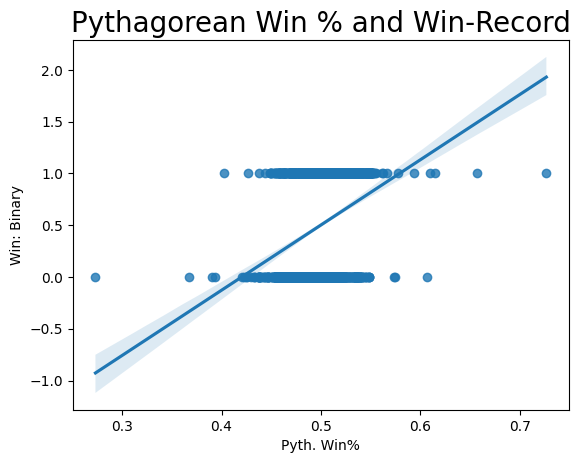

In [ ]:
# Plot the LPM to articulate problems.
sns.regplot(x = 'pyth_wpct', y ='WIN', data = NBA_reg_2017)
plt.xlabel('Pyth. Win%')
plt.ylabel('Win: Binary')
plt.title("Pythagorean Win % and Win-Record", fontsize=20)

In [ ]:
# Fit a logistic regression on win on Pythagorean Winning Percentage.
Win_Pyth = 'WIN~pyth_wpct'
model = smf.glm(formula = Win_Pyth, data = NBA_reg_2017, family=sm.families.Binomial())
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    WIN   No. Observations:                 2378
Model:                            GLM   Df Residuals:                     2376
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1513.6
Date:                Thu, 20 Aug 2026   Deviance:                       3027.3
Time:                        19:33:56   Pearson chi2:                 2.41e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.1071
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -15.2824      1.027    -14.877      0.0

In [ ]:
# Print the results including coefficients, p-values, and dependent variable.
print("Coefficients")
print(result.params)
print("p-Values")
print(result.pvalues)
print("Dependent variables")
print(result.model.endog_names)

Coefficients
Intercept   -15.282377
pyth_wpct    30.573898
dtype: float64
p-Values
Intercept    4.653314e-50
pyth_wpct    3.747873e-50
dtype: float64
Dependent variables
WIN


In [ ]:
# Obtain the fitted probabilities using the logistic regression model.
fittedProbs = result.predict()
print(fittedProbs)

[0.61320335 0.38896784 0.53255106 ... 0.66025312 0.26183995 0.76809196]


In [ ]:
# Based on the fitted probabilites of winning, here we create a binary winning variable for 1 indicating Win (Prob. > 50%), 0 indicating lose (Prob. < 50%)
fittedWin = [1 if x > .5 else 0 for x in fittedProbs]
print(fittedWin[0:10])

[1, 0, 1, 0, 0, 1, 1, 0, 0, 1]


In [ ]:
# Confusion Matrix for Logistic Regression
from sklearn.metrics import confusion_matrix, classification_report
confusion_matrix(NBA_reg_2017['WIN'], fittedWin)

array([[742, 448],
       [389, 799]])

In [ ]:
# Calculate the success rate.
(742 + 799)/2378

0.6480235492010092

In [ ]:
# Show classification report of our last regression
print(classification_report(NBA_reg_2017['WIN'], fittedWin, digits=3))

              precision    recall  f1-score   support

           0      0.656     0.624     0.639      1190
           1      0.641     0.673     0.656      1188

    accuracy                          0.648      2378
   macro avg      0.648     0.648     0.648      2378
weighted avg      0.648     0.648     0.648      2378



In [ ]:
# Fit multiple logistic regression by incorporating the home team advantage.
Win_Pyth_Home = 'WIN~pyth_wpct + Home'
model_2 = smf.glm(formula = Win_Pyth_Home, data = NBA_reg_2017, family=sm.families.Binomial())
result_2 = model_2.fit()
print(result_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    WIN   No. Observations:                 2378
Model:                            GLM   Df Residuals:                     2375
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1481.6
Date:                Thu, 20 Aug 2026   Deviance:                       2963.2
Time:                        19:34:26   Pearson chi2:                 2.41e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1308
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -15.9054      1.049    -15.160      0.0

In [ ]:
# Obtain the fitted results using the logistic regression model.
print("Coefficients")
print(result_2.params)
print("p-Values")
print(result_2.pvalues)
print("Dependent variables")
print(result_2.model.endog_names)

Coefficients
Intercept   -15.905353
pyth_wpct    31.119647
Home          0.700551
dtype: float64
p-Values
Intercept    6.514179e-52
pyth_wpct    3.003712e-50
Home         2.156804e-15
dtype: float64
Dependent variables
WIN


In [ ]:
#we can fit the model to calculate probabilities of winning on each game
fittedProbs_2 = result_2.predict()
print(fittedProbs_2)

[0.69410681 0.30791206 0.44584633 ... 0.58080981 0.33080188 0.70448793]


In [ ]:
# Based on the fitted probabilites of winning, here we create a binary winning variable for 1 indicating Win, 0 indicating lose
fittedWin_2 = [1 if x > .5 else 0 for x in fittedProbs_2]
print(fittedWin_2[0:10])

[1, 0, 0, 1, 0, 1, 1, 0, 0, 1]


In [ ]:
confusion_matrix(NBA_reg_2017['WIN'], fittedWin_2)

array([[787, 403],
       [423, 765]])

In [ ]:
# Calculate the success rate.
(787 + 765)/2378

0.6526492851135408

In [ ]:
print(classification_report(NBA_reg_2017['WIN'], fittedWin_2, digits=3))

              precision    recall  f1-score   support

           0      0.650     0.661     0.656      1190
           1      0.655     0.644     0.649      1188

    accuracy                          0.653      2378
   macro avg      0.653     0.653     0.653      2378
weighted avg      0.653     0.653     0.653      2378

